In [1]:
import pandas as pd
df = pd.read_csv("../Data/Train.csv")
X = df.drop("Reached.on.Time_Y.N", axis=1)
y = df["Reached.on.Time_Y.N"]
print("X shape:", X.shape)

X shape: (1000, 11)


In [2]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
num_cols = X.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X.select_dtypes(include=['object']).columns
num_pipeline = Pipeline([
    ("scaler", StandardScaler())
])
cat_pipeline = Pipeline([
    ("encoder", OneHotEncoder(handle_unknown='ignore'))
])
preprocessor = ColumnTransformer([
    ("num", num_pipeline, num_cols),
    ("cat", cat_pipeline, cat_cols)
])
X_processed = preprocessor.fit_transform(X)
print("Preprocessing done. Shape:", X_processed.shape)

Preprocessing done. Shape: (1000, 20)


In [3]:
from sklearn.ensemble import IsolationForest
import numpy as np
iso_model = IsolationForest(contamination=0.05, random_state=42)
iso_model.fit(X_processed)
iso_pred = iso_model.predict(X_processed)
iso_pred = np.where(iso_pred == -1, 1, 0)
print("Isolation Forest Predictions (1 = anomaly)")
print(np.unique(iso_pred))

Isolation Forest Predictions (1 = anomaly)
[0 1]


In [4]:
from sklearn.svm import OneClassSVM
svm_model = OneClassSVM(kernel='rbf', gamma=0.1)
svm_model.fit(X_processed)
svm_pred = svm_model.predict(X_processed)
svm_pred = np.where(svm_pred == -1, 1, 0)
print("One-Class SVM Predictions (1 = anomaly)")
print(np.unique(svm_pred))

One-Class SVM Predictions (1 = anomaly)
[0 1]


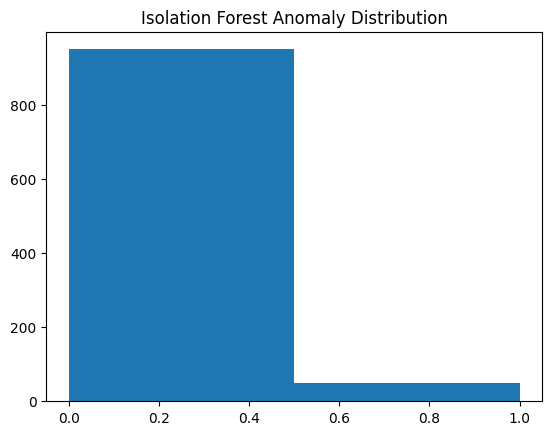

In [5]:
import matplotlib.pyplot as plt
plt.hist(iso_pred, bins=2)
plt.title("Isolation Forest Anomaly Distribution")
plt.show()